# Dallas Animal Shelter FY 2022–2023- Updated

**Tasks:** (1) **Classification** — live vs non-live outcome; (2) **Regression** — length of stay (LOS), days.

**Dataset:** City of Dallas animal shelter intake/outcome records; use the fiscal-year CSV in the `code/` folder or download current exports from [Dallas Open Data](https://www.dallasopendata.com/).

**Workflow:** preprocessing & feature engineering → train/validation/test splits → baseline + advanced models (**Random Forest**, **CatBoost**, **XGBoost**) → metrics → hyperparameter search (XGB) + **5-fold CV** sanity check (classification) → **SHAP** interpretation → held-out test evaluation.

## STEP 0: Imports and configuration
Load core libraries and set global options.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBRegressor
from catboost import CatBoostClassifier

import shap
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

## STEP 1: Load raw data
Read the original Dallas Animal Shelter CSV and inspect basic structure.

In [ ]:
from pathlib import Path
candidate_paths = [
    Path('Dallas_Animal_Shelter_Data_Fiscal_Year_2022_-_2023_20260331.csv'),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'CSV file not found in current notebook folder. '
        f'Tried: {[str(p) for p in candidate_paths]}'
    )

df = pd.read_csv(DATA_PATH, low_memory=False)
print('Using file:', DATA_PATH)
print('Raw shape:', df.shape)
display(df.head())
print(df.dtypes.head())

Using file: Dallas_Animal_Shelter_Data_Fiscal_Year_2022_-_2023_20260331.csv
Raw shape: (34830, 33)


,Animal Id,Animal Type,Animal Breed,Kennel Number,Kennel Status,Activity Number,Activity Sequence,Source Id,Census Tract,Council District,...,Outcome Time,Receipt Number,Impound Number,Service Request Number,Outcome Condition,Chip Status,Animal Origin,Additional Information,Month,Year
0,A0112905,DOG,LABRADOR RETR,FREEZER,IMPOUNDED,NaN,1,P0065664,005300,1,...,12:36:00,NaN,K23-578606,NaN,DECEASED,SCAN CHIP,OVER THE COUNTER,NaN,FY2024,FY2023
1,A0428613,DOG,MIXED BREED,VIP18,AVAILABLE,NaN,1,P1030009,NaN,NaN,...,19:15:00,R23-603480,K23-593168,NaN,APP WNL,SCAN NO CHIP,OVER THE COUNTER,NaN,FY2024,FY2023
2,A0428613,DOG,MIXED BREED,AD 085,IMPOUNDED,NaN,1,P0868753,005600,4,...,18:01:00,R23-598578,K23-575038,NaN,APP WNL,SCAN NO CHIP,OVER THE COUNTER,BBW,FY2024,FY2023
3,A0499062,DOG,POODLE MIN,INJD 014,PRE-LAB,A23-366883,1,P1036135,008704,4,...,13:07:00,NaN,K23-579268,NaN,APP INJ,SCAN CHIP,FIELD,DMF,FY2024,FY2023
4,A0520592,DOG,SCHNAUZER MIN,LFD 083,UNAVAILABLE,NaN,1,P0746568,NaN,NaN,...,12:58:00,NaN,K22-569686,NaN,APP WNL,SCAN CHIP,OVER THE COUNTER,NaN,FY2024,FY2023


Animal Id        str
Animal Type      str
Animal Breed     str
Kennel Number    str
Kennel Status    str
dtype: object


## STEP 2: Missingness and basic EDA
Check missing values, outcome distribution, and generate basic plots.

Columns with missing values:
Service Request Number    34817
Receipt Number            24174
Additional Information    22528
Activity Number           21766
Census Tract              13002
Council District          13002
Hold Request              10018
Outcome Condition          4980
Reason                     4936
Chip Status                4936
Animal Origin              4936
Animal Breed                 42
dtype: int64


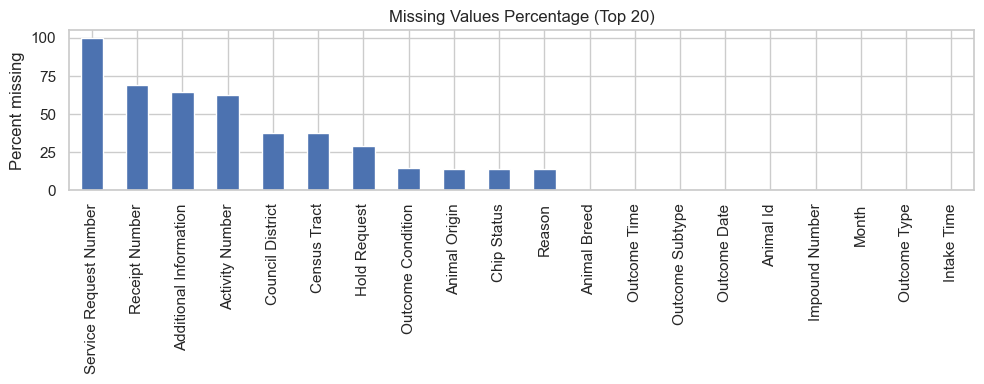

Outcome Type counts:
Outcome Type
ADOPTION             8838
EUTHANIZED           7752
FOSTER               4261
LOST EXP             3550
TRANSFER             3481
RETURNED TO OWNER    2857
TREATMENT            1450
FOUND EXP            1386
DIED                  486
WILDLIFE              302
DISPOSAL              242
SNR                   172
MISSING                53
Name: count, dtype: int64


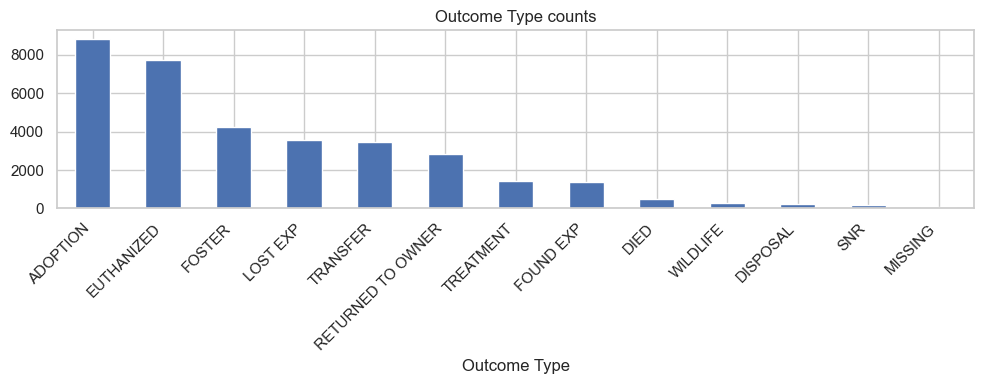

In [ ]:
# Missing values summary
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing.sort_values(ascending=False))

# Missingness bar plot
plt.figure(figsize=(10,4))
(df.isnull().mean()*100).sort_values(ascending=False).head(20).plot(kind='bar')
plt.ylabel('Percent missing')
plt.title('Missing Values Percentage (Top 20)')
plt.tight_layout()
plt.show()

# Outcome Type distribution
if 'Outcome Type' in df.columns:
    print('Outcome Type counts:')
    print(df['Outcome Type'].value_counts(dropna=False))

    plt.figure(figsize=(10,4))
    df['Outcome Type'].value_counts().plot(kind='bar')
    plt.title('Outcome Type counts')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## STEP 3: Basic cleaning (dates, text standardization)
Convert date columns to datetime and standardize key text columns.

In [ ]:
# Drop obviously unhelpful high-missing admin column early
if 'Service Request Number' in df.columns:
    df = df.drop(columns=['Service Request Number'])

# Convert dates to datetime
for col in ['Intake Date', 'Outcome Date', 'Due Out']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Standardize key text columns to uppercase
text_cols = [c for c in ['Animal Type', 'Animal Breed', 'Intake Type', 'Outcome Type'] if c in df.columns]
for col in text_cols:
    df[col] = df[col].astype(str).str.upper().str.strip()

# Fill some important categorical NAs
if 'Animal Breed' in df.columns:
    df['Animal Breed'] = df['Animal Breed'].fillna('UNKNOWN')
if 'Outcome Condition' in df.columns:
    df['Outcome Condition'] = df['Outcome Condition'].fillna('UNKNOWN')

print('Duplicates in full df:', df.duplicated().sum())
print('Repeated Animal Ids:', df['Animal Id'].duplicated().sum() if 'Animal Id' in df.columns else 'N/A')

Duplicates in full df: 0
Repeated Animal Ids: 5962


## STEP 4: Build Intake/Outcome datetimes and LOS
- Create Intake Datetime and Outcome Datetime, then compute Length_of_Stay.

Removed negative LOS rows: 37


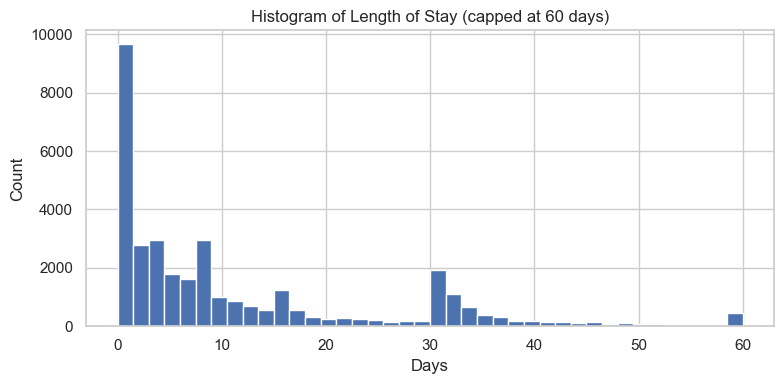

In [ ]:
# Combine date + time into datetimes
if 'Intake Time' in df.columns:
    df['Intake Datetime'] = pd.to_datetime(df['Intake Date'].astype(str) + ' ' + df['Intake Time'].astype(str), errors='coerce')
else:
    df['Intake Datetime'] = df['Intake Date']

if 'Outcome Time' in df.columns:
    df['Outcome Datetime'] = pd.to_datetime(df['Outcome Date'].astype(str) + ' ' + df['Outcome Time'].astype(str), errors='coerce')
else:
    df['Outcome Datetime'] = df['Outcome Date']

# Length of stay in days
df['Length_of_Stay'] = (df['Outcome Datetime'] - df['Intake Datetime']).dt.total_seconds() / (24*60*60)

# Remove impossible negative LOS
before = df.shape[0]
df = df[df['Length_of_Stay'].isna() | (df['Length_of_Stay'] >= 0)]
after = df.shape[0]
print('Removed negative LOS rows:', before - after)

plt.figure(figsize=(8,4))
(df['Length_of_Stay'].dropna().clip(upper=60)).hist(bins=40)
plt.title('Histogram of Length of Stay (capped at 60 days)')
plt.xlabel('Days')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## STEP 4b: Deduplicate by Animal ID
Keep only the most recent intake per animal to avoid bias toward repeat intakes.

In [ ]:
before_dedup = df.shape[0]
df = df.sort_values('Intake Datetime', ascending=True).drop_duplicates(subset=['Animal Id'], keep='last')
after_dedup = df.shape[0]

print(f'Removed duplicate animal intakes: {before_dedup - after_dedup} rows')
print(f'Unique animals: {df["Animal Id"].nunique()}')
print(f'Remaining shape: {df.shape}')

Removed duplicate animal intakes: 5950 rows
Unique animals: 28843
Remaining shape: (28843, 35)


## STEP 5: Drop high-missing and identifier columns
Remove columns with extreme missingness or ID-only information.

In [ ]:
# Drop additional high-missing admin fields
high_missing_drop = ['Receipt Number', 'Additional Information', 'Activity Number']
for col in high_missing_drop:
    if col in df.columns:
        df = df.drop(columns=[col])

# Identifier-like columns
id_like_cols = ['Animal Id', 'Source Id', 'Staff Id', 'Impound Number']
for col in id_like_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

print('Shape after dropping admin and ID cols:', df.shape)

Shape after dropping admin and ID cols: (28843, 28)


## STEP 6: Numeric type fixes and missing-value imputation
Fix mixed numeric columns and fill categorical gaps with a fixed token. **Numeric medians are fit only on training data** inside the Step 12 `Pipeline`, so test rows do not influence imputation statistics.

In [ ]:
# Convert mixed numeric columns where appropriate
for col in ['Census Tract', 'Council District']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill categorical NAs with 'UNKNOWN' (excluding Outcome Type). Constant fill — no train/test leakage.
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if col != 'Outcome Type':
        df[col] = df[col].fillna('UNKNOWN')

# Numeric columns: keep NaNs here. Step 12 uses SimpleImputer(strategy='median') inside each model
# Pipeline, so medians are learned only on the training fold (validation/test medians do not leak in).

print('Remaining missing (top 10) — expect numeric NaNs until Step 12 pipelines fit on train:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

Remaining missing (top 10) — expect numeric NaNs until Step 12 pipelines fit on train:
Census Tract        10970
Council District    10970
Animal Type             0
Hold Request            0
Outcome Datetime        0
Intake Datetime         0
Year                    0
Month                   0
Animal Origin           0
Chip Status             0
dtype: int64


## STEP 7: Intake-based temporal features
Create intake month, weekday, year, weekend flag, and hour.

In [ ]:
df['Intake_Month'] = df['Intake Date'].dt.month
df['Intake_DayOfWeek'] = df['Intake Date'].dt.dayofweek
df['Intake_Year'] = df['Intake Date'].dt.year
df['Intake_IsWeekend'] = df['Intake_DayOfWeek'].isin([5,6]).astype(int)

if 'Intake Time' in df.columns:
    df['Intake Time'] = pd.to_datetime(df['Intake Time'], format='%H:%M:%S', errors='coerce')
    df['Intake_Hour'] = df['Intake Time'].dt.hour
else:
    df['Intake_Hour'] = df['Intake Datetime'].dt.hour

print(df[['Intake_Month','Intake_DayOfWeek','Intake_Year','Intake_IsWeekend','Intake_Hour']].head())

      Intake_Month  Intake_DayOfWeek  Intake_Year  Intake_IsWeekend  \
1888            10                 5         2022                 1   
4750            10                 5         2022                 1   
2685            10                 5         2022                 1   
2686            10                 5         2022                 1   
2687            10                 5         2022                 1   

      Intake_Hour  
1888            0  
4750            7  
2685            7  
2686            9  
2687            9  


## STEP 8: Group rare categories
Reduce noise by grouping rare levels into 'OTHER' for selected fields.

In [ ]:
def group_rare_categories(df_in, column, threshold=50):
    counts = df_in[column].value_counts()
    rare_categories = counts[counts < threshold].index
    df_in[column] = df_in[column].replace(rare_categories, 'OTHER')
    return df_in

for col in ['Animal Breed', 'Intake Subtype', 'Reason', 'Animal Origin']:
    if col in df.columns:
        print(f'Before grouping {col}:', df[col].nunique())
        df = group_rare_categories(df, col, threshold=50)
        print(f'After grouping {col}:', df[col].nunique())

print(df[['Animal Breed','Intake Subtype','Reason','Animal Origin']].head())

Before grouping Animal Breed: 262
After grouping Animal Breed: 46
Before grouping Intake Subtype: 38
After grouping Intake Subtype: 22
Before grouping Reason: 18
After grouping Reason: 14
Before grouping Animal Origin: 9
After grouping Animal Origin: 6
     Animal Breed Intake Subtype      Reason     Animal Origin
1888  DOMESTIC SH          OTHER       OTHER  OVER THE COUNTER
4750     SHIH TZU            WEB     UNKNOWN           UNKNOWN
2685        BOXER       AT LARGE  OTHRINTAKS             FIELD
2686  DOMESTIC SH       CONFINED       OTHER  OVER THE COUNTER
2687  DOMESTIC SH       CONFINED       OTHER  OVER THE COUNTER


## STEP 9: Define Live vs Non-live outcome label
Map Outcome Type into Live_Outcome (1) vs Non_live (0).

Live_Outcome
0    14559
1    14284
Name: count, dtype: int64


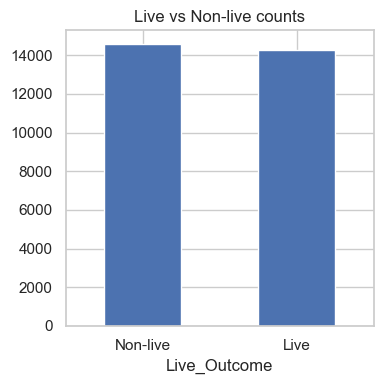

In [ ]:
live_outcomes = [
    'ADOPTION',
    'RETURNED TO OWNER',
    'TRANSFER',
    'RESCUE',
    'FOSTER',
]

outcome_type = df['Outcome Type'].fillna('UNKNOWN').str.upper()
df['Live_Outcome'] = np.where(outcome_type.isin(live_outcomes), 1, 0)

print(df['Live_Outcome'].value_counts())
plt.figure(figsize=(4,4))
df['Live_Outcome'].value_counts().plot(kind='bar')
plt.title('Live vs Non-live counts')
plt.xticks([0,1],["Non-live","Live"], rotation=0)
plt.tight_layout()
plt.show()

## STEP 9b: Remove data leakage columns
Drop 7 columns that encode post-intake state or outcome proxies. These caused unrealistically high 0.92–0.96 AUC in earlier versions.
- **Kennel Status, Intake Condition, Activity Sequence, Kennel Number** — post-intake location/state
- **Hold Request, Intake Subtype, Reason** — administrative outcome-predetermined codes (e.g., "SAC"=99.9% euthanize, "FOR ADOPT"=99.6% live)

In [ ]:
# Remove columns that encode post-intake state or outcome history
leakage_cols_to_drop = [
    'Kennel Status',       # Post-intake location (LAB=euthanize, AVAILABLE=adopt): 99.8% predictive
    'Intake Condition',    # Encodes medical/outcome state (DECEASED=already dead, NORMAL=100% non-live)
    'Activity Sequence',   # Encodes prior intake history (0=single intake→death, 1=repeat→adopt)
    'Kennel Number',       # Specific kennel codes correlate with section fate
    'Hold Request',        # Admin codes: SAC=99.9% non-live, EUTH=88% non-live, ADOP RESCU=85% live
    'Intake Subtype',      # Pre-determined outcomes: WEB=100% non-live, RABIES=100% non-live, DIED=100% non-live, SAC=96% non-live
    'Reason',              # Outcome-labeled: FOR ADOPT=99.6% live, TRANSFER=99% live, UNKNOWN=100% non-live
]

before_drop = df.shape[1]
for col in leakage_cols_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f'Dropped {col}')

after_drop = df.shape[1]
print(f'\nRemoved {before_drop - after_drop} leakage columns')
print(f'Remaining features: {after_drop}')

Dropped Kennel Status
Dropped Intake Condition
Dropped Activity Sequence
Dropped Kennel Number
Dropped Hold Request
Dropped Intake Subtype
Dropped Reason

Removed 7 leakage columns
Remaining features: 27


## STEP 10: Build modeling datasets (classification & regression)
Create intake-only feature matrices for live vs non-live and LOS tasks, excluding post-outcome variables.

In [ ]:
# Columns that must NOT be used as predictors for classification (leakage)
leakage_cols = [
    'Outcome Type',  # Live_Outcome is derived from this; using it would leak the target
    'Outcome Subtype',
    'Outcome Date',
    'Outcome Time',
    'Outcome Condition',
    'Outcome Datetime',
    'Length_of_Stay',  # LOS is target for regression
]

# Drop raw datetime fields after creating engineered temporal features
datetime_raw_cols = ['Intake Date', 'Intake Time', 'Intake Datetime', 'Due Out']

# Drop fiscal-period labels; keep engineered intake temporal features instead
raw_period_cols = ['Month', 'Year']

# --- Classification dataframe ---
classification_df = df.copy()

# Exclude TREATMENT: the shelter closes the record when the animal leaves for external care,
# not when it reaches a final outcome. 81.4% of TREATMENT records have LOS < 1 day and
# the animal's eventual fate is untracked in this dataset — including them as non-live
# adds label noise to the binary target.
n_treatment = (classification_df['Outcome Type'] == 'TREATMENT').sum()
classification_df = classification_df[classification_df['Outcome Type'] != 'TREATMENT']
print(f'Excluded TREATMENT records from classification: {n_treatment}')

classification_df = classification_df.drop(
    columns=[c for c in leakage_cols + datetime_raw_cols + raw_period_cols if c in classification_df.columns],
    errors='ignore'
)

X_class = classification_df.drop(columns=['Live_Outcome'], errors='ignore')
y_class = classification_df['Live_Outcome']  # use filtered index, not original df

print('Classification features shape:', X_class.shape)
print('Class balance after TREATMENT exclusion:')
print(y_class.value_counts())

# --- Regression dataframe ---
# Cap LOS at 365 days: records beyond one fiscal year are likely data-entry errors.
LOS_CAP = 365
n_over_cap = (df['Length_of_Stay'].notna() & (df['Length_of_Stay'] > LOS_CAP)).sum()
regression_df = df[df['Length_of_Stay'].notna() & (df['Length_of_Stay'] <= LOS_CAP)].copy()
print(f'\nRemoved {n_over_cap} records with LOS > {LOS_CAP} days from regression')

regression_drop_cols = [
    'Outcome Type',
    'Outcome Subtype',
    'Outcome Date',
    'Outcome Time',
    'Outcome Condition',
    'Outcome Datetime',
    'Live_Outcome',
]
regression_df = regression_df.drop(
    columns=[c for c in regression_drop_cols + datetime_raw_cols + raw_period_cols if c in regression_df.columns],
    errors='ignore',
)

X_reg = regression_df.drop(columns=['Length_of_Stay'], errors='ignore')
y_reg = regression_df['Length_of_Stay']

print('Regression features shape:', X_reg.shape)
print(f'Regression LOS range after cap: min={y_reg.min():.1f}  max={y_reg.max():.1f} days')

print('\nSample classification columns:')
print(X_class.columns[:20])

Excluded TREATMENT records from classification: 645
Classification features shape: (28198, 13)
Class balance after TREATMENT exclusion:
Live_Outcome
1    14284
0    13914
Name: count, dtype: int64

Removed 29 records with LOS > 365 days from regression
Regression features shape: (28814, 13)
Regression LOS range after cap: min=0.0  max=354.3 days

Sample classification columns:
Index(['Animal Type', 'Animal Breed', 'Census Tract', 'Council District',
       'Intake Type', 'Intake Total', 'Chip Status', 'Animal Origin',
       'Intake_Month', 'Intake_DayOfWeek', 'Intake_Year', 'Intake_IsWeekend',
       'Intake_Hour'],
      dtype='str')


## STEP 11: Train/validation/test split
Split classification and regression data, with stratification for live vs non-live.

In [ ]:
Xc_train, Xc_temp, yc_train, yc_temp = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)
Xc_val, Xc_test, yc_val, yc_test = train_test_split(
    Xc_temp, yc_temp, test_size=0.5, random_state=42, stratify=yc_temp
)

Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp, yr_temp, test_size=0.5, random_state=42
)

print('Classification splits:', Xc_train.shape, Xc_val.shape, Xc_test.shape)
print('Regression splits:', Xr_train.shape, Xr_val.shape, Xr_test.shape)


Classification splits: (22558, 13) (2820, 13) (2820, 13)
Regression splits: (23051, 13) (2881, 13) (2882, 13)


## STEP 12: Preprocessing pipeline
`ColumnTransformer` with **median imputation fit on training data** + one-hot encoding for categoricals (constant fill for any remaining categorical NA).

In [ ]:
# Classification preprocessor (SimpleImputer medians are fit only on rows passed to Pipeline.fit — train)
cat_cols = Xc_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = Xc_train.select_dtypes(include=['number']).columns.tolist()

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cls_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_cols),
        ('num', num_transformer, num_cols),
    ]
)

# Keep `preprocessor` name for classification cells that already reference it.
preprocessor = cls_preprocessor

# Regression preprocessor (different feature set from classification)
reg_cat_cols = Xr_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
reg_num_cols = Xr_train.select_dtypes(include=['number']).columns.tolist()

reg_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), reg_cat_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), reg_num_cols),
    ]
)

print('Classification categorical cols:', len(cat_cols))
print('Classification numeric cols:', len(num_cols))
print('Datetime cols in Xc_train:', Xc_train.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns.tolist())
print('Regression categorical cols:', len(reg_cat_cols))
print('Regression numeric cols:', len(reg_num_cols))
print('Datetime cols in Xr_train:', Xr_train.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns.tolist())


Classification categorical cols: 5
Classification numeric cols: 8
Datetime cols in Xc_train: []
Regression categorical cols: 5
Regression numeric cols: 8
Datetime cols in Xr_train: []


## STEP 12b: Stratified 5-fold CV (classification)
**Minimal robustness check** — stratified **5-fold** on **train ∪ validation** only (the test set from Step 11 is **not** used here). Reports **mean ± std** ROC-AUC for the same three models as Steps 13–14. Single-split training and Step 18 test evaluation are unchanged.

In [ ]:
# Train ∪ val only — test rows excluded (same 80% as train+val combined)
Xc_trainval = pd.concat([Xc_train, Xc_val])
yc_trainval = pd.concat([yc_train, yc_val])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

_cv_pipelines = [
    ('Logistic regression', Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', LogisticRegression(max_iter=1000)),
    ])),
    ('Random Forest', Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ])),
    ('CatBoost', Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model', CatBoostClassifier(
            iterations=200,
            depth=6,
            learning_rate=0.1,
            loss_function='Logloss',
            random_seed=42,
            verbose=False,
            thread_count=-1,
        )),
    ])),
]

print(
    f'Stratified 5-fold ROC-AUC (train∪val, n={len(yc_trainval)}); test set not used.'
)
for name, pipe in _cv_pipelines:
    scores = cross_val_score(
        pipe,
        Xc_trainval,
        yc_trainval,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1,
    )
    print(
        f'  {name}: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.array2string(scores, precision=4)})'
    )

Stratified 5-fold ROC-AUC (train∪val, n=25378); test set not used.
  Logistic regression: 0.8691 ± 0.0040  (folds: [0.8649 0.8649 0.8749 0.8683 0.8726])
  Random Forest: 0.9125 ± 0.0024  (folds: [0.909  0.9102 0.9139 0.9138 0.9153])
  CatBoost: 0.9082 ± 0.0037  (folds: [0.9047 0.903  0.9126 0.9091 0.9114])


## STEP 13: Baseline classification model
**Logistic regression** baseline; Step 14 uses **Random Forest** and **CatBoost** (same preprocessing, no resampling).

Logistic Regression validation report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      1391
           1       0.75      0.96      0.84      1429

    accuracy                           0.81      2820
   macro avg       0.84      0.81      0.81      2820
weighted avg       0.84      0.81      0.81      2820

Validation ROC-AUC (LR): 0.8652609824529276


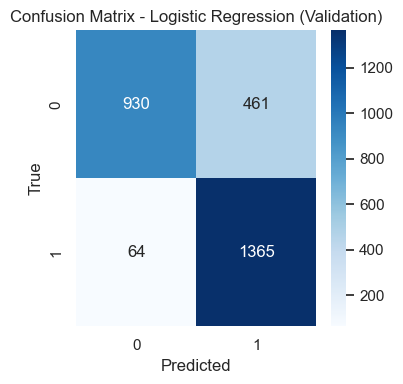

In [ ]:
# Logistic regression baseline
clf_lr = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000)),
])

clf_lr.fit(Xc_train, yc_train)
yc_val_pred_lr = clf_lr.predict(Xc_val)
yc_val_proba_lr = clf_lr.predict_proba(Xc_val)[:, 1]

print('Logistic Regression validation report:')
print(classification_report(yc_val, yc_val_pred_lr))
print('Validation ROC-AUC (LR):', roc_auc_score(yc_val, yc_val_proba_lr))

# Confusion matrix heatmap
cm_lr = confusion_matrix(yc_val, yc_val_pred_lr)
plt.figure(figsize=(4,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


## STEP 14: Advanced classification models
After the logistic baseline — **Random Forest** and **CatBoost**; validation ROC-AUC picks the model refit once on test (Step 18). **Validation ROC curves** compare LR, RF, and CatBoost on the same fold (run Step 13 first for `yc_val_proba_lr`).

**Hyperparameters:** RF and CatBoost use **fixed** settings documented in code. **Systematic tuning** is applied to **XGBoost** for LOS in Step 16 (random search + early stopping).


Random Forest validation report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1391
           1       0.81      0.89      0.85      1429

    accuracy                           0.84      2820
   macro avg       0.84      0.84      0.84      2820
weighted avg       0.84      0.84      0.84      2820

Validation ROC-AUC (Random Forest): 0.917027336083862


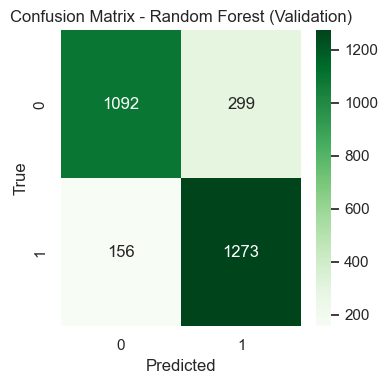

CatBoost validation report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.83      1391
           1       0.79      0.94      0.86      1429

    accuracy                           0.85      2820
   macro avg       0.86      0.84      0.84      2820
weighted avg       0.86      0.85      0.84      2820

Validation ROC-AUC (CatBoost): 0.9105076169456855


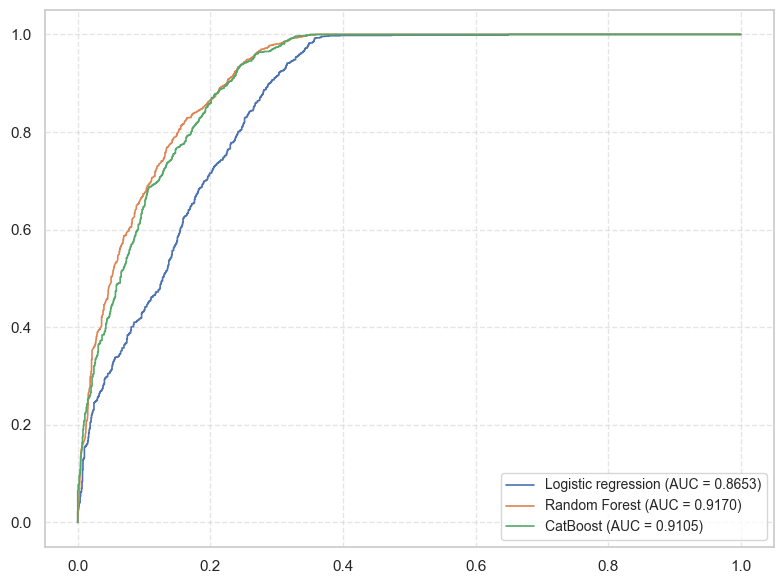

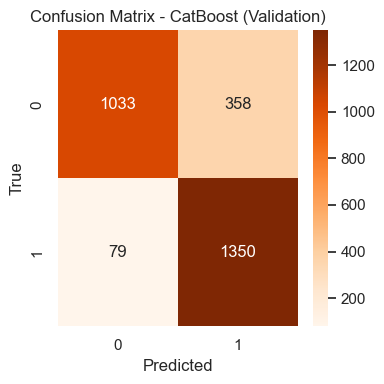

Best classifier on validation (by ROC-AUC): RandomForest


In [ ]:
# Advanced classifiers (after logistic baseline): Random Forest + CatBoost
rf_clf = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

rf_clf.fit(Xc_train, yc_train)
yc_val_pred_rf = rf_clf.predict(Xc_val)
yc_val_proba_rf = rf_clf.predict_proba(Xc_val)[:, 1]
auc_rf = roc_auc_score(yc_val, yc_val_proba_rf)

print('Random Forest validation report:')
print(classification_report(yc_val, yc_val_pred_rf))
print('Validation ROC-AUC (Random Forest):', auc_rf)

cm_rf = confusion_matrix(yc_val, yc_val_pred_rf)
plt.figure(figsize=(4, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest (Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

cat_clf = Pipeline([
    ('preprocess', preprocessor),
    ('model', CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        random_seed=42,
        verbose=False,
        thread_count=-1,
    )),
])

cat_clf.fit(Xc_train, yc_train)
yc_val_pred_cat = cat_clf.predict(Xc_val)
yc_val_proba_cat = cat_clf.predict_proba(Xc_val)[:, 1]
auc_cat = roc_auc_score(yc_val, yc_val_proba_cat)

print('CatBoost validation report:')
print(classification_report(yc_val, yc_val_pred_cat))
print('Validation ROC-AUC (CatBoost):', auc_cat)

# Validation ROC curves (requires Step 13 logistic probabilities on the same validation fold)
plt.figure(figsize=(8, 6))

for name, proba, color in [
    ('Logistic regression', yc_val_proba_lr, 'C0'),
    ('Random Forest', yc_val_proba_rf, 'C1'),
    ('CatBoost', yc_val_proba_cat, 'C2'),
]:
    fpr, tpr, _ = roc_curve(yc_val, proba)
    auc_m = roc_auc_score(yc_val, proba)
    plt.plot(fpr, tpr, lw=1.2, color=color, label=f'{name} (AUC = {auc_m:.4f})')

# plt.xlim(0.0, 0.2)
# plt.ylim(0.8, 1.01)

# plt.xlabel('False positive rate (Zoomed 0.0 - 0.2)')
# plt.ylabel('True positive rate (Zoomed 0.8 - 1.0)')
# plt.title('ROC Curves Comparison (Zoomed Top-Left)')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

cm_cat = confusion_matrix(yc_val, yc_val_pred_cat)
plt.figure(figsize=(4, 4))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - CatBoost (Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

if auc_rf >= auc_cat:
    best_clf_name = 'RandomForest'
    best_clf_pipeline = rf_clf
else:
    best_clf_name = 'CatBoost'
    best_clf_pipeline = cat_clf

print('Best classifier on validation (by ROC-AUC):', best_clf_name)

## STEP 14b: Threshold calibration
All three classifiers over-predict "live" at the default 0.5 threshold (non-live recall 66–79% vs live recall 90–95%). Find the **Youden-optimal threshold** from the RF validation ROC curve to balance the two classes.

Youden-optimal threshold: 0.369  (default: 0.500)

--- Default threshold (0.500) ---
              precision    recall  f1-score   support

    Non-live       0.88      0.79      0.83      1391
        Live       0.81      0.89      0.85      1429

    accuracy                           0.84      2820
   macro avg       0.84      0.84      0.84      2820
weighted avg       0.84      0.84      0.84      2820

Balanced accuracy: 0.8379

--- Calibrated threshold (0.369) ---
              precision    recall  f1-score   support

    Non-live       0.93      0.75      0.83      1391
        Live       0.79      0.95      0.86      1429

    accuracy                           0.85      2820
   macro avg       0.86      0.85      0.85      2820
weighted avg       0.86      0.85      0.85      2820

Balanced accuracy: 0.8469

AUC is a ranking metric — unchanged by threshold: 0.9170


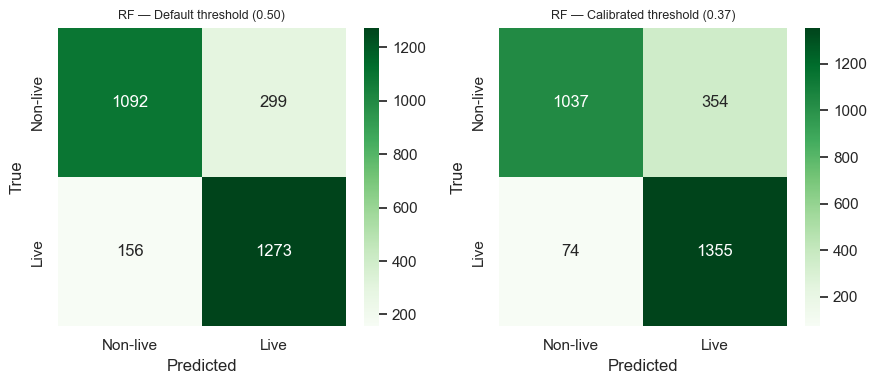

In [ ]:
from sklearn.metrics import balanced_accuracy_score

# Youden's J = TPR - FPR; maximising this balances sensitivity and specificity.
fpr_rf, tpr_rf, thresh_rf = roc_curve(yc_val, yc_val_proba_rf)
youden_j = tpr_rf - fpr_rf
optimal_idx = int(np.argmax(youden_j))
optimal_threshold = float(thresh_rf[optimal_idx])

yc_val_pred_rf_cal = (yc_val_proba_rf >= optimal_threshold).astype(int)

print(f'Youden-optimal threshold: {optimal_threshold:.3f}  (default: 0.500)')
print()
print('--- Default threshold (0.500) ---')
print(classification_report(yc_val, yc_val_pred_rf, target_names=['Non-live', 'Live']))
print(f'Balanced accuracy: {balanced_accuracy_score(yc_val, yc_val_pred_rf):.4f}')
print()
print(f'--- Calibrated threshold ({optimal_threshold:.3f}) ---')
print(classification_report(yc_val, yc_val_pred_rf_cal, target_names=['Non-live', 'Live']))
print(f'Balanced accuracy: {balanced_accuracy_score(yc_val, yc_val_pred_rf_cal):.4f}')
print()
print(f'AUC is a ranking metric — unchanged by threshold: {roc_auc_score(yc_val, yc_val_proba_rf):.4f}')

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, preds, title in zip(
    axes,
    [yc_val_pred_rf, yc_val_pred_rf_cal],
    ['RF — Default threshold (0.50)', f'RF — Calibrated threshold ({optimal_threshold:.2f})'],
):
    cm = confusion_matrix(yc_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['Non-live', 'Live'], yticklabels=['Non-live', 'Live'])
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

## STEP 15: Baseline LOS regression model
**Linear regression** baseline (sole baseline before XGBoost). Target is **log(1 + LOS)** with **`TransformedTargetRegressor`**; metrics below are **back in days** via `expm1`.

--- Linear regression (validation): raw LOS vs log1p target ---
  Raw target     — MAE: 7.2752  RMSE: 16.7321  R²: 0.3418
  log(1+LOS) target (metrics in days) — MAE: 6.5108  RMSE: 17.0498  R²: 0.3166
  (sanity) pred in days: min/max = 0.00 / 49.68; true LOS min/max = 0.00 / 348.86


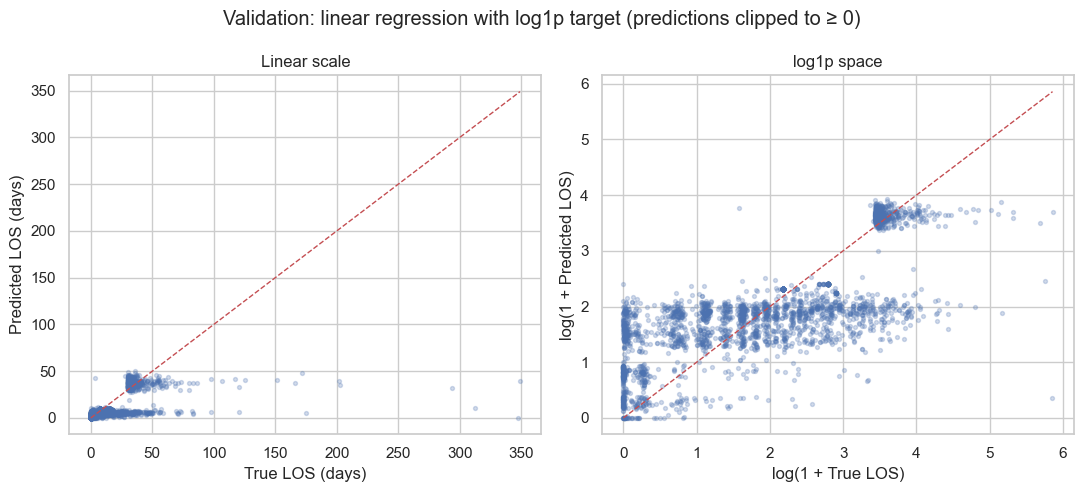

In [ ]:
# Baseline: linear regression on raw LOS vs log1p(LOS); all reported metrics are in days.
reg_lr_raw = Pipeline([
    ('preprocess', clone(reg_preprocessor)),
    ('model', LinearRegression()),
])
reg_lr_raw.fit(Xr_train, yr_train)
yr_val_pred_raw = np.maximum(0, reg_lr_raw.predict(Xr_val))  # clip: LOS cannot be negative
mae_raw = mean_absolute_error(yr_val, yr_val_pred_raw)
rmse_raw = root_mean_squared_error(yr_val, yr_val_pred_raw)
r2_raw = r2_score(yr_val, yr_val_pred_raw)

reg_lr = TransformedTargetRegressor(
    regressor=Pipeline([
        ('preprocess', clone(reg_preprocessor)),
        ('model', LinearRegression()),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)
reg_lr.fit(Xr_train, yr_train)
yr_val_pred_lr = np.maximum(0, reg_lr.predict(Xr_val))  # clip: LOS cannot be negative

print('--- Linear regression (validation): raw LOS vs log1p target ---')
print(f'  Raw target     — MAE: {mae_raw:.4f}  RMSE: {rmse_raw:.4f}  R²: {r2_raw:.4f}')
print(f'  log(1+LOS) target (metrics in days) — MAE: {mean_absolute_error(yr_val, yr_val_pred_lr):.4f}'
      f'  RMSE: {root_mean_squared_error(yr_val, yr_val_pred_lr):.4f}'
      f'  R²: {r2_score(yr_val, yr_val_pred_lr):.4f}')

_yt = np.asarray(yr_val).ravel()
_yp = np.asarray(yr_val_pred_lr).ravel()
print(
    f'  (sanity) pred in days: min/max = {_yp.min():.2f} / {_yp.max():.2f}; '
    f'true LOS min/max = {_yt.min():.2f} / {_yt.max():.2f}'
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(_yt, _yp, alpha=0.25, s=8)
axes[0].plot([_yt.min(), _yt.max()], [_yt.min(), _yt.max()], 'r--', lw=1)
axes[0].set_xlabel('True LOS (days)')
axes[0].set_ylabel('Predicted LOS (days)')
axes[0].set_title('Linear scale')
axes[1].scatter(np.log1p(_yt), np.log1p(_yp), alpha=0.25, s=8)
lo, hi = np.log1p(_yt).min(), np.log1p(_yt).max()
axes[1].plot([lo, hi], [lo, hi], 'r--', lw=1)
axes[1].set_xlabel('log(1 + True LOS)')
axes[1].set_ylabel('log(1 + Predicted LOS)')
axes[1].set_title('log1p space')
fig.suptitle('Validation: linear regression with log1p target (predictions clipped to ≥ 0)')
plt.tight_layout()
plt.show()

## STEP 16: Advanced LOS regression model
**XGBoost** with validation-based tuning. Target is **log(1 + LOS)** (same as Step 15); tuning minimizes squared error in log-space; **best trial is chosen by validation R² in days** after `expm1`. Prints validation MAE / RMSE / R² in **days**. Refit on train+val for test in Step 18.

In [ ]:
# NOTE: This cell uses early stopping + random search (NO sklearn KFold / RandomizedSearchCV).
# XGBoost: train on log1p(LOS); compare metrics in original days via expm1(predictions).

rng = np.random.RandomState(42)
_xgb_pre = clone(reg_preprocessor)
Xtr = _xgb_pre.fit_transform(Xr_train, yr_train)
Xva = _xgb_pre.transform(Xr_val)
ytr = np.asarray(yr_train).ravel()
yva = np.asarray(yr_val).ravel()
ytr_log = np.log1p(ytr)
yva_log = np.log1p(yva)


def _sample_xgb_params(rng):
    return {
        'max_depth': int(rng.randint(4, 11)),
        'learning_rate': float(rng.choice([0.03, 0.04, 0.05, 0.06, 0.08, 0.1])),
        'subsample': float(rng.choice([0.65, 0.75, 0.8, 0.85, 0.9, 1.0])),
        'colsample_bytree': float(rng.choice([0.65, 0.75, 0.8, 0.85, 0.9, 1.0])),
        'min_child_weight': int(rng.choice([1, 2, 3, 5, 7, 10])),
        'reg_alpha': float(rng.choice([0, 0.01, 0.05, 0.1, 0.5, 1, 3])),
        'reg_lambda': float(rng.choice([0.5, 1, 2, 4, 8, 12, 20])),
        'gamma': float(rng.choice([0, 0.01, 0.05, 0.1, 0.3, 0.6, 1.5])),
    }


def _tune_xgb_log_target(n_iter, rng, n_estimators_cap=2500, early_stopping_rounds=80):
    """Random trials on log1p(y); pick best validation R² in original days (after expm1)."""
    best = None
    for t in range(n_iter):
        p = _sample_xgb_params(rng)
        m = XGBRegressor(
            n_estimators=n_estimators_cap,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            early_stopping_rounds=early_stopping_rounds,
            **p,
        )
        m.fit(Xtr, ytr_log, eval_set=[(Xva, yva_log)], verbose=False)
        pred_log = m.predict(Xva)
        pred_days = np.expm1(pred_log)
        r2_days = r2_score(yva, pred_days)
        mae_days = mean_absolute_error(yva, pred_days)
        if best is None or r2_days > best['r2_days']:
            best = {
                'params': p,
                'n_trees': int(m.best_iteration) + 1,
                'r2_days': r2_days,
                'mae_days': mae_days,
            }
    return best


N_ITER = 12
N_ESTIMATORS_CAP = 2500
print(
    f'Tuning XGB on log1p(LOS) (reg:squarederror): {N_ITER} trials, '
    f'n_estimators cap {N_ESTIMATORS_CAP}, early stopping on validation...'
)
best_sq = _tune_xgb_log_target(N_ITER, rng, n_estimators_cap=N_ESTIMATORS_CAP)
print('Best params:', best_sq['params'])
print(
    '  trees:', best_sq['n_trees'],
    '| val R² (days):', best_sq['r2_days'],
    '| val MAE (days):', best_sq['mae_days'],
)

sq_trees = best_sq['n_trees']
sq_params = best_sq['params']
xgb_reg = TransformedTargetRegressor(
    regressor=Pipeline([
        ('preprocess', clone(reg_preprocessor)),
        ('model', XGBRegressor(
            n_estimators=sq_trees,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            **sq_params,
        )),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)
xgb_reg.fit(Xr_train, yr_train)

yr_val_pred_xgb = xgb_reg.predict(Xr_val)
print('XGBoost LOS MAE (validation, days):', mean_absolute_error(yr_val, yr_val_pred_xgb))
print('XGBoost LOS RMSE (validation, days):', root_mean_squared_error(yr_val, yr_val_pred_xgb))
print('XGBoost LOS R2 (validation, days):', r2_score(yr_val, yr_val_pred_xgb))

best_reg_name = 'XGBoost'
best_reg_pipeline = xgb_reg

Tuning XGB on log1p(LOS) (reg:squarederror): 12 trials, n_estimators cap 2500, early stopping on validation...
Best params: {'max_depth': 7, 'learning_rate': 0.04, 'subsample': 1.0, 'colsample_bytree': 0.9, 'min_child_weight': 5, 'reg_alpha': 0.0, 'reg_lambda': 0.5, 'gamma': 0.05}
  trees: 783 | val R² (days): 0.3932507847677438 | val MAE (days): 5.563769861698245
XGBoost LOS MAE (validation, days): 5.563769861698245
XGBoost LOS RMSE (validation, days): 16.064835860468072
XGBoost LOS R2 (validation, days): 0.3932507847677438


## STEP 16b: Regression model comparison table
Side-by-side metrics: Linear Regression (baseline) vs XGBoost (tuned).

In [ ]:
# Recalculate linear regression metrics on log1p target for clean comparison (predictions clipped ≥ 0)
yr_val_pred_lr_recalc = np.maximum(0, reg_lr.predict(Xr_val))
lr_mae  = mean_absolute_error(yr_val, yr_val_pred_lr_recalc)
lr_rmse = root_mean_squared_error(yr_val, yr_val_pred_lr_recalc)
lr_r2   = r2_score(yr_val, yr_val_pred_lr_recalc)

comparison_df = pd.DataFrame({
    'Model':       ['Linear Regression', 'XGBoost'],
    'MAE (days)':  [lr_mae,  best_sq['mae_days']],
    'RMSE (days)': [lr_rmse, root_mean_squared_error(yr_val, yr_val_pred_xgb)],
    'R² (days)':   [lr_r2,   best_sq['r2_days']],
})

print('=' * 70)
print('Regression Model Comparison (Validation Set)')
print('=' * 70)
display(comparison_df.round(4))
print(f'\nBest model: {best_reg_name} (highest R²)')
print('=' * 70)

Regression Model Comparison (Validation Set)


,Model,MAE (days),RMSE (days),R² (days)
0,Linear Regression,6.5108,17.0498,0.3166
1,XGBoost,5.5638,16.0648,0.3933



Best model: XGBoost (highest R²)


## STEP 17: SHAP interpretability for classification
Compute SHAP values for a sample using the **Step 14 validation winner** (clone + fit on the SHAP subsample).

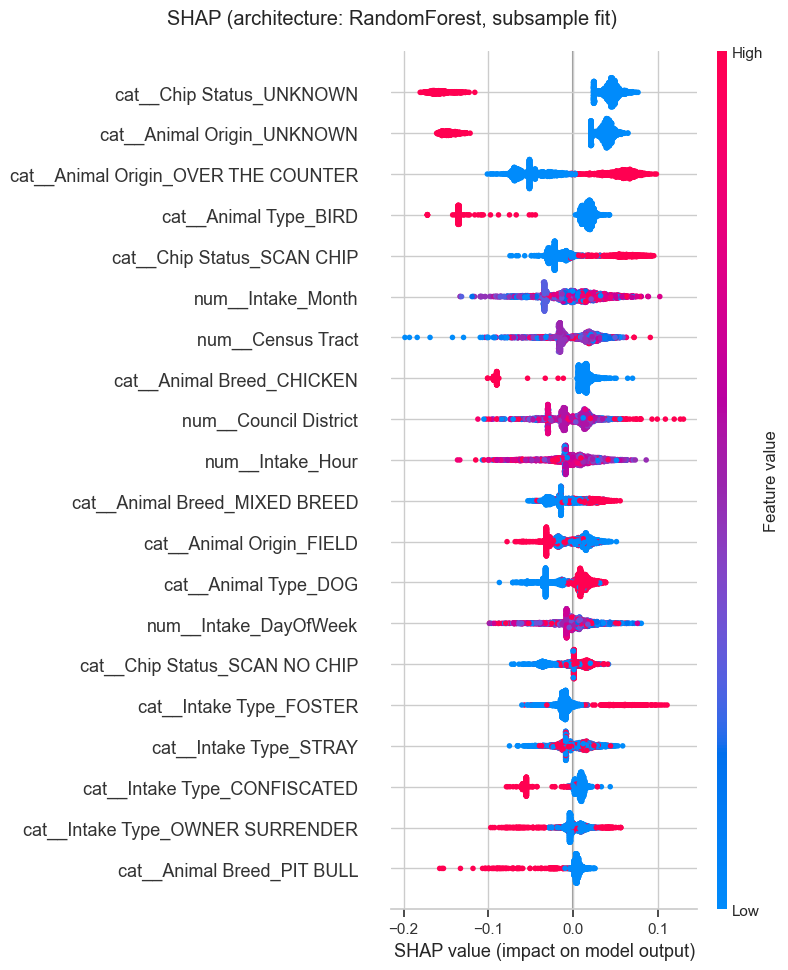

In [ ]:
# Sample for SHAP: same architecture as Step 14 winner, fit once on subsample (no extra full-train model)
sample_idx = Xc_train.sample(n=min(2000, len(Xc_train)), random_state=42).index
X_shap = Xc_train.loc[sample_idx]
y_shap = yc_train.loc[sample_idx]

shap_pipe = clone(best_clf_pipeline)
shap_pipe.fit(X_shap, y_shap)

X_shap_transformed = shap_pipe.named_steps['preprocess'].transform(X_shap)
if hasattr(X_shap_transformed, 'toarray'):
    X_shap_transformed = X_shap_transformed.toarray()
X_shap_transformed = np.asarray(X_shap_transformed, dtype=np.float32)

feature_names = shap_pipe.named_steps['preprocess'].get_feature_names_out()
model_shap = shap_pipe.named_steps['model']

explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_shap_transformed)

if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_for_plot = shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
else:
    shap_values_for_plot = shap_values

shap.summary_plot(
    shap_values_for_plot,
    X_shap_transformed,
    feature_names=feature_names,
    show=False,
)
plt.suptitle(f'SHAP (architecture: {best_clf_name}, subsample fit)', y=1.02)
plt.show()

## STEP 17b: Random Forest local SHAP (force plots)
**Matplotlib force plots** for the **positive class (live = 1)** on the validation set: one **true positive** (pred live, true live) and one **false positive** (pred live, true non-live). Uses the Step 14 **`rf_clf`** (already fit on `Xc_train`).

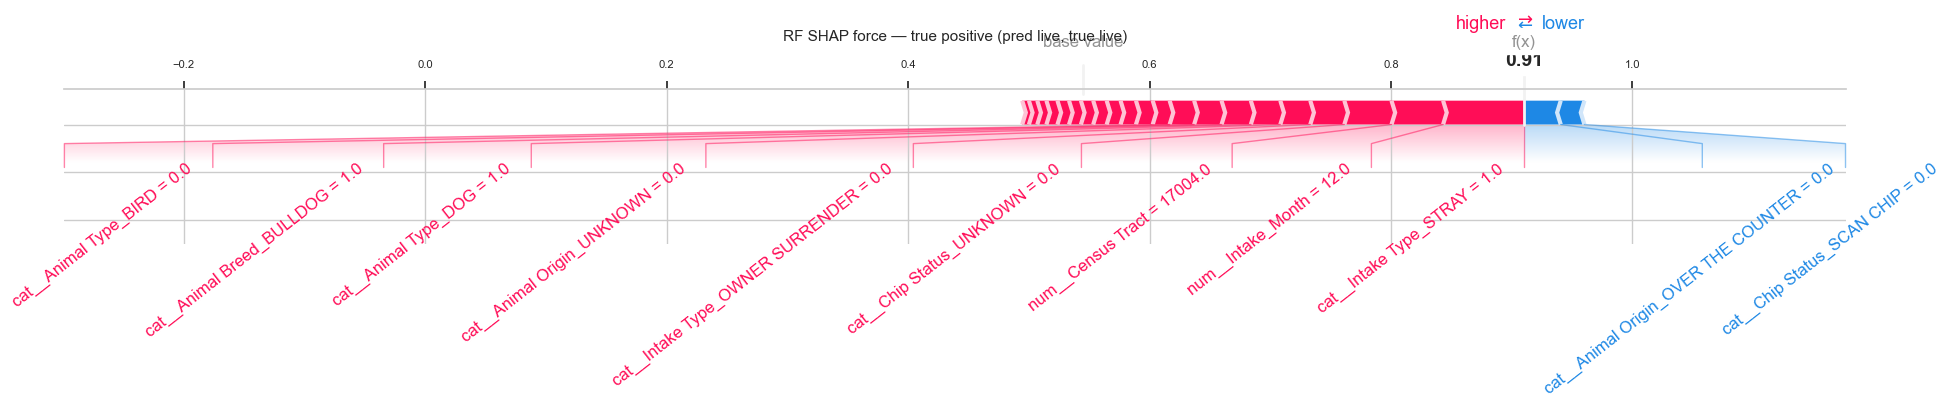

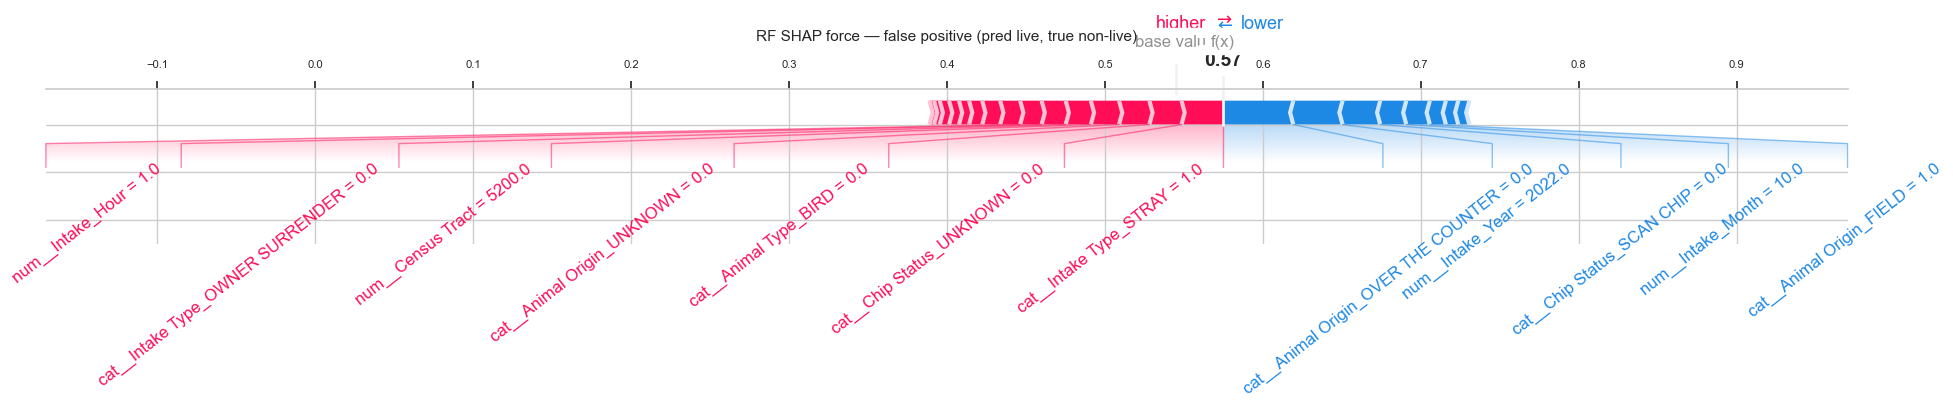

Validation iloc used — TP: 2 | FP: 3
Force plots: top 22 features by |SHAP| plus one combined "Other" bar if needed.


In [ ]:
# Random Forest — two local SHAP force plots (TP + FP), validation fold, positive class = live (1)
# Labels: show top-K drivers with full names + one "Other" bar (remaining SHAP mass)

rf_model = rf_clf.named_steps['model']
rf_pre = rf_clf.named_steps['preprocess']

yc_val_arr = np.asarray(yc_val)
mask_tp = (yc_val_arr == 1) & (yc_val_pred_rf == 1)
mask_fp = (yc_val_arr == 0) & (yc_val_pred_rf == 1)

if not mask_tp.any():
    raise ValueError('No true positives on validation for the current RF predictions.')
if not mask_fp.any():
    raise ValueError('No false positives on validation for the current RF predictions.')

pos_tp = int(np.flatnonzero(mask_tp)[0])
pos_fp = int(np.flatnonzero(mask_fp)[0])

bg_n = min(300, len(Xc_train))
X_bg = rf_pre.transform(Xc_train.sample(bg_n, random_state=42))
if hasattr(X_bg, 'toarray'):
    X_bg = X_bg.toarray()
X_bg = np.asarray(X_bg, dtype=np.float32)

explainer_rf = shap.TreeExplainer(rf_model, X_bg)
feat_names = rf_pre.get_feature_names_out()


def _positive_class_shap_vector(x_dense_2d):
    """x_dense_2d: (1, n_features) after preprocessing."""
    sv = explainer_rf.shap_values(x_dense_2d)
    if isinstance(sv, list):
        row = np.ravel(sv[1][0])
        eva = np.asarray(explainer_rf.expected_value).ravel()
        base = float(eva[1]) if eva.size > 1 else float(eva[0])
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        row = np.ravel(sv[0, :, 1])
        eva = np.asarray(explainer_rf.expected_value).ravel()
        base = float(eva[1]) if eva.size > 1 else float(eva[0])
    else:
        row = np.ravel(sv[0])
        base = float(np.asarray(explainer_rf.expected_value).ravel()[0])
    return row, base


def _maybe_trim_label(s, max_chars=58):
    s = str(s)
    if len(s) <= max_chars:
        return s
    a = max_chars // 2 - 2
    b = max_chars - a - 3
    return s[:a] + '...' + s[-b:]


def _compress_topk_other(row, feats, names, top_k=22):
    """Keep top_k |SHAP| features with readable labels; aggregate the rest into one bar (label shows count)."""
    row = np.asarray(row, dtype=float).ravel()
    feats = np.asarray(feats, dtype=float).ravel()
    names = [str(n) for n in names]
    n = row.size
    top_k = int(min(top_k, n))
    order_big = np.argsort(-np.abs(row))[:top_k]
    mask_other = np.ones(n, dtype=bool)
    mask_other[order_big] = False
    other_sum = float(row[mask_other].sum())
    n_other = int(mask_other.sum())

    row_parts = row[order_big].tolist()
    feat_parts = feats[order_big].tolist()
    name_parts = [_maybe_trim_label(names[i]) for i in order_big]

    if n_other > 0:
        row_parts.append(other_sum)
        feat_parts.append(float(np.nanmedian(feats)))
        name_parts.append(f'Other ({n_other} features, combined SHAP)')

    row_s = np.asarray(row_parts, dtype=float)
    feats_s = np.asarray(feat_parts, dtype=float)
    names_s = name_parts
    vis_order = np.argsort(-np.abs(row_s))
    return row_s[vis_order], feats_s[vis_order], [names_s[i] for i in vis_order]


def _plot_rf_force(val_pos_iloc, title, top_k=22):
    X_one = Xc_val.iloc[[val_pos_iloc]]
    Xt = rf_pre.transform(X_one)
    if hasattr(Xt, 'toarray'):
        Xt = Xt.toarray()
    Xt = np.asarray(Xt, dtype=float)
    row, base = _positive_class_shap_vector(Xt)
    feats = np.ravel(Xt)
    row_s, feats_s, names_s = _compress_topk_other(
        row, feats, feat_names, top_k=top_k,
    )
    shap.force_plot(
        base,
        row_s,
        feats_s,
        feature_names=names_s,
        matplotlib=True,
        show=False,
        figsize=(20, 5),
        text_rotation=38,
    )
    fig = plt.gcf()
    for ax in fig.axes:
        ax.tick_params(axis='x', labelsize=8, pad=8)
    plt.title(title, fontsize=11, pad=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    plt.show()


TOP_K = 22
_plot_rf_force(pos_tp, 'RF SHAP force — true positive (pred live, true live)', top_k=TOP_K)
_plot_rf_force(pos_fp, 'RF SHAP force — false positive (pred live, true non-live)', top_k=TOP_K)
print('Validation iloc used — TP:', pos_tp, '| FP:', pos_fp)
print('Force plots: top', TOP_K, 'features by |SHAP| plus one combined "Other" bar if needed.')

## STEP 18: Final test evaluation
**Clone** the Step 14 validation winner (Random Forest vs CatBoost), refit on train+val for classification; **clone** the Step 16 **XGBoost** (`log1p` LOS target) and refit on train+val for LOS. Printed LOS metrics are in **days** (inverse `expm1`).

=== Final TEST — RandomForest ===

--- Default threshold (0.50) ---
              precision    recall  f1-score   support

    Non-live       0.88      0.78      0.83      1392
        Live       0.81      0.90      0.85      1428

    accuracy                           0.84      2820
   macro avg       0.85      0.84      0.84      2820
weighted avg       0.85      0.84      0.84      2820

ROC-AUC: 0.9151
Balanced accuracy: 0.8425

--- Calibrated threshold (0.369) ---
              precision    recall  f1-score   support

    Non-live       0.93      0.74      0.83      1392
        Live       0.79      0.95      0.86      1428

    accuracy                           0.85      2820
   macro avg       0.86      0.84      0.84      2820
weighted avg       0.86      0.85      0.84      2820

ROC-AUC: 0.9151  (unchanged)
Balanced accuracy: 0.8437


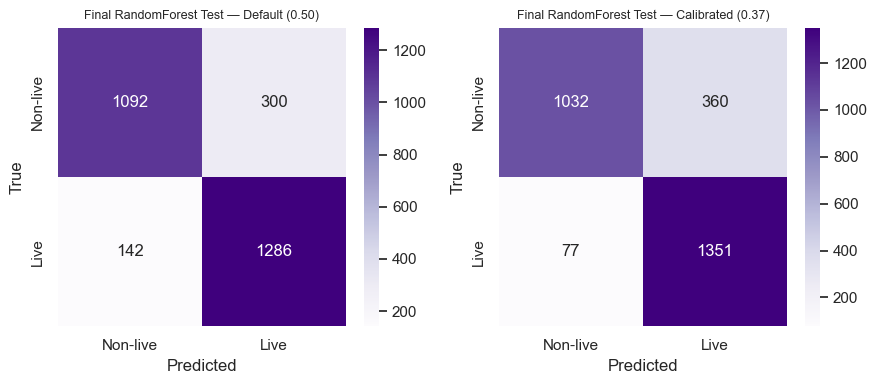


=== Final TEST — XGBoost (LOS regression) ===
MAE:  4.9855 days
RMSE: 11.1665 days
R²:   0.5327


In [ ]:
# Classification: refit validation winner once on train+val (same hyperparameters as Step 14)
Xc_trainval = pd.concat([Xc_train, Xc_val])
yc_trainval = pd.concat([yc_train, yc_val])

final_clf = clone(best_clf_pipeline)
final_clf.fit(Xc_trainval, yc_trainval)
yc_test_proba = final_clf.predict_proba(Xc_test)[:, 1]

# Default threshold (0.50)
yc_test_pred_default = final_clf.predict(Xc_test)

# Calibrated threshold from Step 14b (Youden-optimal on validation)
yc_test_pred_cal = (yc_test_proba >= optimal_threshold).astype(int)

print(f'=== Final TEST — {best_clf_name} ===')
print(f'\n--- Default threshold (0.50) ---')
print(classification_report(yc_test, yc_test_pred_default, target_names=['Non-live', 'Live']))
print(f'ROC-AUC: {roc_auc_score(yc_test, yc_test_proba):.4f}')
print(f'Balanced accuracy: {balanced_accuracy_score(yc_test, yc_test_pred_default):.4f}')

print(f'\n--- Calibrated threshold ({optimal_threshold:.3f}) ---')
print(classification_report(yc_test, yc_test_pred_cal, target_names=['Non-live', 'Live']))
print(f'ROC-AUC: {roc_auc_score(yc_test, yc_test_proba):.4f}  (unchanged)')
print(f'Balanced accuracy: {balanced_accuracy_score(yc_test, yc_test_pred_cal):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, preds, title in zip(
    axes,
    [yc_test_pred_default, yc_test_pred_cal],
    [f'Final {best_clf_name} Test — Default (0.50)',
     f'Final {best_clf_name} Test — Calibrated ({optimal_threshold:.2f})'],
):
    cm = confusion_matrix(yc_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Non-live', 'Live'], yticklabels=['Non-live', 'Live'])
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

# Regression: refit validation winner once on train+val (same hyperparameters as Step 16)
Xr_trainval = pd.concat([Xr_train, Xr_val])
yr_trainval = pd.concat([yr_train, yr_val])

final_reg = clone(best_reg_pipeline)
final_reg.fit(Xr_trainval, yr_trainval)
yr_test_pred = final_reg.predict(Xr_test)

print(f'\n=== Final TEST — {best_reg_name} (LOS regression) ===')
print(f'MAE:  {mean_absolute_error(yr_test, yr_test_pred):.4f} days')
print(f'RMSE: {root_mean_squared_error(yr_test, yr_test_pred):.4f} days')
print(f'R²:   {r2_score(yr_test, yr_test_pred):.4f}')

In [ ]:
import sys, importlib
from pathlib import Path

p = str(Path("../agentic/prediction_app").resolve())
if p not in sys.path:
    sys.path.insert(0, p)

import save_artifacts
print("using:", save_artifacts.__file__)  # must point to prediction_app/save_artifacts.py
importlib.reload(save_artifacts)
print("has conditional_levels:", "conditional_levels" in open(save_artifacts.__file__).read())

# optional: remove old bundle first
out = Path("../agentic/prediction_app/artifacts/bundle.joblib").resolve()
if out.exists():
    out.unlink()

save_artifacts.save_bundle(final_clf, final_reg, X_class, X_reg)
print("saved:", out)

using: /Users/tnt/Desktop/UTA study/2nd Sem/ASDS6302 MACHINE LEARNING WITH APPLICATIONS/final project/agentic/prediction_app/save_artifacts.py
has conditional_levels: True
Saved: /Users/tnt/Desktop/UTA study/2nd Sem/ASDS6302 MACHINE LEARNING WITH APPLICATIONS/final project/agentic/prediction_app/artifacts/bundle.joblib
saved: /Users/tnt/Desktop/UTA study/2nd Sem/ASDS6302 MACHINE LEARNING WITH APPLICATIONS/final project/agentic/prediction_app/artifacts/bundle.joblib
